# Pythonic process Based Modeling 
Implements process-based modeling into python.

## Implementation 
- **on surface**: process-based modeling (entities & processes)
- **low level**: just **variables** & **constants** 

PBM implementation: [PyBM/src/pybm/model.py](/home/urhp/Documents/PyBM/src/pybm/model.py)

Estimation using Scipy: [PyBM/src/pybm/estimate/int_scipy.py](/home/urhp/Documents/PyBM/src/pybm/estimate/int_scipy.py)

Estimation using Torch: [PyBM/src/pybm/estimate/int_torch.py](/home/urhp/Documents/PyBM/src/pybm/estimate/int_torch.py)

## Syntax
No more type annotations.

In [1]:
from pybm.model import VarTemp, ConstTemp, EntityTemp, Model, Var

# new particle template 
particle_template = EntityTemp(
    VarTemp("x"),
    VarTemp("y"),
    ConstTemp("k", initial_value=0.5)
)
# create one instance of the template
neon_particle = particle_template(name="neon_particle")

# create another and add a new variable to it
higgs_boson = particle_template(name="higgs_boson")
# add a new variable to the higgs_boson instance
higgs_boson.add(Var("spin"))

# create a new model
particle_model = Model(neon_particle, higgs_boson)

print(str(particle_model))

Model(Entities: ['neon_particle', 'higgs_boson'],
 Vars: ['neon_particle.x', 'neon_particle.y', 'higgs_boson.x', 'higgs_boson.y', 'higgs_boson.spin'],
 Consts: ['neon_particle.k', 'higgs_boson.k'])


Less is more. No need for templates.

In [2]:
from pybm.model import Var, Const, Entity

# Entities, variables and constants can be created directly.
v1 = Var("x")
v2 = Var("y")
c1 = Const("mass", initial_value=0.5)
particle = Entity(v1, v2, c1, name="particle")

small_particle_model = Model(particle)
print(str(small_particle_model))

Model(Entities: ['particle'],
 Vars: ['particle.x', 'particle.y'],
 Consts: ['particle.mass'])


## Example 
This small predator-prey model will work as a example. We have two wariables:
- $n_{\mathrm{prey}}(t)$: prey population size,
- $n_{\mathrm{predator}}(t)$: predator population size.

Growth of both populations is effected by *exo* variable **temperature**, which folows this equation:
$$
T(t) = 1 + A \sin\left(\frac{2\pi t}{P}\right),
$$
where $A=2$.

### Processes

The prey population grows at a temperature-dependent rate:

$$
\mathrm{Growth}_{\mathrm{prey}}
=
T(t)\,r_{\mathrm{prey}}\,n_{\mathrm{prey}}(t).
$$

Predators have a temperature-dependent background mortality:

$$
\mathrm{Background}_{\mathrm{predator}}
=
T(t)\,r_{\mathrm{predator}}\,n_{\mathrm{predator}}(t),
$$

Where $r_{\mathrm{predator}} < 0$.

Predation removes prey:

$$
\mathrm{Predation}
=
a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

A fraction $e$ of consumed prey is converted into predator population growth:

$$
\mathrm{Predator\ gain}
=
e\,a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

## Ordinary differential equations

The prey ODE is the sum of prey growth and the negative predation contribution:

$$
\frac{d n_{\mathrm{prey}}}{dt}
=
T(t)\,r_{\mathrm{prey}}\,n_{\mathrm{prey}}(t)
-
a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

The predator ODE is the sum of background mortality and gain from predation:

$$
\frac{d n_{\mathrm{predator}}}{dt}
=
T(t)\,r_{\mathrm{predator}}\,n_{\mathrm{predator}}(t)
+
e\,a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

## Constants

The synthetic-data example uses the following constants:

- $A = 0.2$: amplitude of temperature variation.
- $P = 10.0$: temperature period, in days.
- $r_{\mathrm{prey}} = 0.5$: baseline prey growth rate.
- $r_{\mathrm{predator}} = -0.2$: baseline predator growth or mortality rate.
- $a = 0.02$: predation rate.
- $e = 0.1$: conversion efficiency from consumed prey to predator growth.

The initial conditions are:

$$
n_{\mathrm{prey}}(0) = 40,
$$

$$
n_{\mathrm{predator}}(0) = 8.
$$

Implementation of the model is in [/PyBM/src/pybm/examples/predator_prey.py](/home/urhp/Documents/PyBM/src/pybm/examples/predator_prey.py)

In [3]:
from pybm.examples.predator_prey import  generate_synthetic_data

# Generate model and data from /home/urhp/Documents/PyBM/src/pybm/examples/predator_prey.py
model, components, times = generate_synthetic_data()
print(str(model))

# print initial values of the variables
print("Initial values of the variables:")
for var_name, var in model.vars.items():
    print(f"{var_name}: {var.initial}")  

# set initial values of the constants to true values
model.consts["growth_rate_prey"].initial_value = 0.5
model.consts["growth_rate_predator"].initial_value = -0.1
model.consts["predation_rate"].initial_value = 0.02 #0.02
model.consts["conversion_efficiency"].initial_value = 0.1#0.1

# set initial values of the constants to good guesses
# model.consts["growth_rate_prey"].initial_value = 0.4
# model.consts["growth_rate_predator"].initial_value = -0.1
# model.consts["predation_rate"].initial_value = 0.05 #0.02
# model.consts["conversion_efficiency"].initial_value = 0.2#0.1

# set initial values of the constants to bad guesses
# model.consts["growth_rate_prey"].initial_value = 0.1 #0.5
# model.consts["growth_rate_predator"].initial_value = 0.1 #-0.2
# model.consts["predation_rate"].initial_value = 0.1 #0.02
# model.consts["conversion_efficiency"].initial_value = 0.2#0.1


# print initial values of the constants
print("\nInitial values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {const.initial_value}")


Model(Entities: [],
 Vars: ['n_prey', 'n_predator', 'temperature'],
 Consts: ['growth_rate_prey', 'growth_rate_predator', 'predation_rate', 'conversion_efficiency'])
Initial values of the variables:
n_prey: 40.000492061342996
n_predator: 8.016754323781468
temperature: None

Initial values of the constants:
growth_rate_prey: 0.5
growth_rate_predator: -0.1
predation_rate: 0.02
conversion_efficiency: 0.1


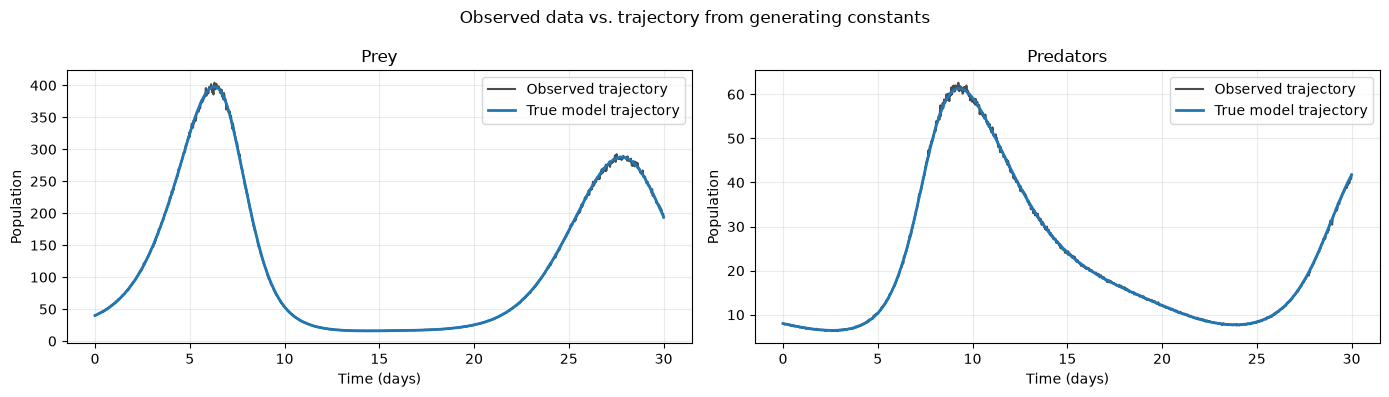

In [4]:
import matplotlib.pyplot as plt
from pybm.examples.predator_prey import (
    GROWTH_RATE_PREY,
    GROWTH_RATE_PREDATOR,
    PREDATION_RATE,
    CONVERSION_EFFICIENCY,
)
from pybm.estimate.int_scipy import simulate as simulate_scipy

# Simulate the model with the true generating constants.
true_const_ctx = [
    GROWTH_RATE_PREY,
    GROWTH_RATE_PREDATOR,
    PREDATION_RATE,
    CONVERSION_EFFICIENCY,
]
sol = simulate_scipy(
    *model.get_endo_variables(),
    t_eval=times,
    const_ctx=true_const_ctx,
 )

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

series = [
    ("n_prey", "Prey"),
    ("n_predator", "Predators"),
]

for index, (name, title) in enumerate(series):
    ax = axes[index]
    observed = components[name].data.x

    ax.plot(
        times, observed,
        label="Observed trajectory",
        color="black",
        alpha=0.7,
    )
    ax.plot(
        times, sol.y[index],
        label="True model trajectory",
        color="tab:blue",
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Observed data vs. trajectory from generating constants")
fig.tight_layout()
plt.show()

Estimate 

In [ ]:
from pybm.estimate.int_scipy import estimate as estimate_scipy

# first set initial values of the constants to bad guesses
model.consts["growth_rate_prey"].initial_value = 0.1 #0.5
model.consts["growth_rate_predator"].initial_value = 0.1 #-0.2
model.consts["predation_rate"].initial_value = 0.1 #0.02
model.consts["conversion_efficiency"].initial_value = 0.2#0.1

# use multishooting with more subintervals to estimate the constants of the model
results = estimate_scipy(model=model, t_eval=times, verbose=2, n_subintervals=100, 
                                    max_iter=10000, gtol=1e-8, method="least_squares", max_offset=1e3)  # verbose=2 for more detailed output

SyntaxError: positional argument follows keyword argument (60786742.py, line 11)

In [ ]:
const_values = results.x[:len(model.consts)]

In [ ]:
for const_name, const in model.consts.items():
    # set new estimated values to the model constants 
    const.initial_value = const_values[const.index_in_ctx]

# dictionary of names and true values of the constants for comparison
true_const_values = {
    "growth_rate_prey": 0.5,
    "growth_rate_predator": -0.1,
    "predation_rate": 0.02,
    "conversion_efficiency": 0.1
}

# print the estimated values of the constants
print("\nEstimated values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {round(const.initial_value, 2)}, true value: {true_const_values[const_name]}")


Estimated values of the constants:
growth_rate_prey: 0.49, true value: 0.5
growth_rate_predator: -0.21, true value: -0.1
predation_rate: 0.02, true value: 0.02
conversion_efficiency: 0.11, true value: 0.1


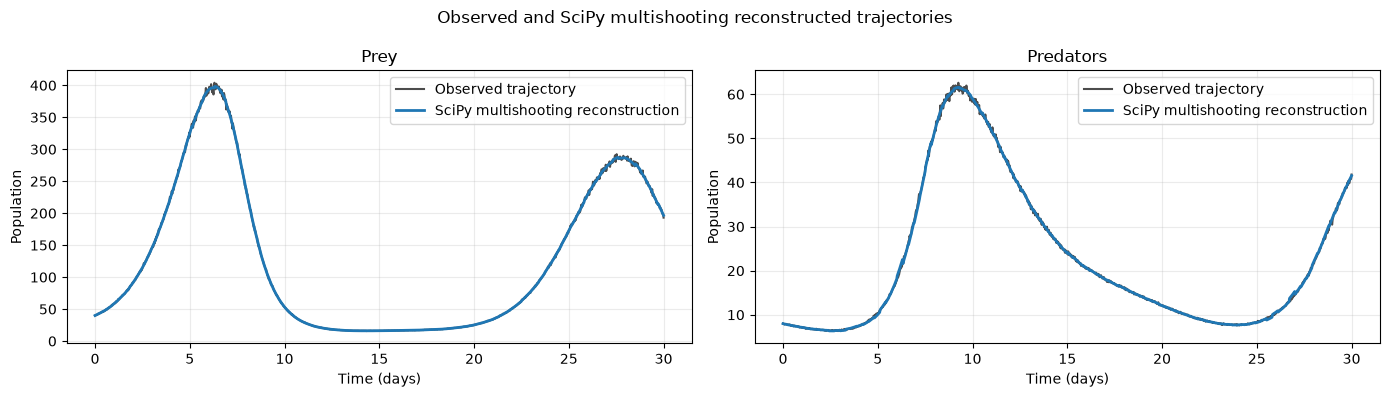

In [ ]:
import importlib
import matplotlib.pyplot as plt
import pybm.estimate.int_scipy as int_scipy_module

int_scipy_module = importlib.reload(int_scipy_module)
simulate_multishooting_scipy = int_scipy_module.simulate_multishooting

# Reconstruct the fitted multishooting trajectory from the full parameter vector.
fitted_solution = simulate_multishooting_scipy(
    *model.get_endo_variables(),
    t_eval=times,
    params=results.x,
    n_consts=len(model.consts),
    n_subintervals=100,
 )

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

series = [
    ("n_prey", "Prey"),
    ("n_predator", "Predators"),
]

for index, (name, title) in enumerate(series):
    ax = axes[index]
    observed = components[name].data.x

    ax.plot(
        times, observed,
        label="Observed trajectory",
        color="black",
        alpha=0.7,
    )
    ax.plot(
        times, fitted_solution.y[index],
        label="SciPy multishooting reconstruction",
        color="tab:blue",
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Observed and SciPy multishooting reconstructed trajectories")
fig.tight_layout()
plt.show()

In [ ]:
raise NotImplementedError("Stop here to check the estimated constants and fitted trajectories before proceeding to PyTorch estimation.")

NotImplementedError: Stop here to check the estimated constants and fitted trajectories before proceeding to PyTorch estimation.

## Torch optimisation (autograd)

In [ ]:
from pybm.estimate.int_torch import estimate as estimate_torch
import torch
# set initial values of the constants to good guesses
model.consts["growth_rate_prey"].initial_value = 0.5
model.consts["growth_rate_predator"].initial_value = -0.1
model.consts["predation_rate"].initial_value = 0.05
model.consts["conversion_efficiency"].initial_value = 0.05
# torch - change numpy arrays to torch tensors
for var_name, var in model.vars.items():
    if var.data is not None:
        var.data.to_torch()
# change times to a torch tensor
t_eval = torch.tensor(times, requires_grad=True)
# reshape into (1, n_times)
#t_eval = torch.reshape(t_eval, (1, -1))

In [ ]:
#const_values_torch, loss_torch = estimate_torch(model=model, t_eval=t_eval,
#                                                line_search_fn="strong_wolfe", lr=0.1, max_iter=50,
#                                                tolerance_grad=1e-03, tolerance_change=1e-05)  # verbose=2 for more detailed output
const_values_torch, loss_torch = estimate_torch(model=model, t_eval=t_eval, 
                                                opt="adam", lr=0.01, max_iter=200)  


print("Loss: ", loss_torch)

Loss:  0.008541863710712189


In [ ]:
# update model constants with estimated values
for const_name, const in model.consts.items():
    const.initial_value = const_values_torch[const.index_in_ctx].item()

print("\nEstimated values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {round(const.initial_value, 2)}, true value: {true_const_values[const_name]}")


Estimated values of the constants:
growth_rate_prey: 0.6, true value: 0.5
growth_rate_predator: -0.16, true value: -0.1
predation_rate: 0.03, true value: 0.02
conversion_efficiency: 0.05, true value: 0.1


/home/urhp/Documents/PyBM/src/pybm/estimate/int_scipy.py:158: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  derivatives[var.index_in_ctx] = var.ode(t, new_ctx)


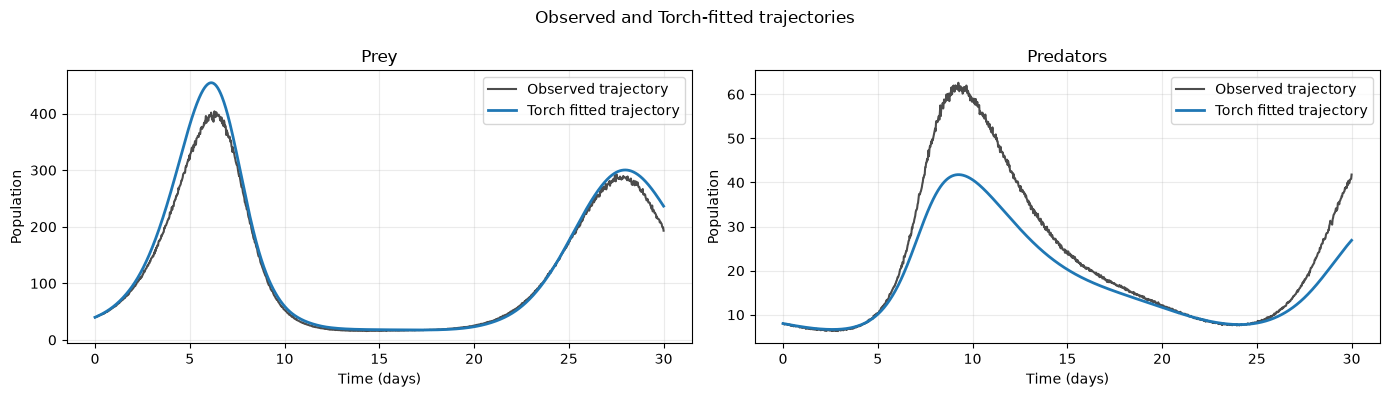

In [ ]:
import matplotlib.pyplot as plt
from pybm.estimate.int_scipy import simulate as simulate_scipy

# Simulacija z ocenjenimi SciPy parametri
fitted_solution = simulate_scipy(
    *model.get_endo_variables(),
    t_eval=times,
    const_ctx=const_values_torch,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

series = [
    ("n_prey", "Prey"),
    ("n_predator", "Predators"),
]

for index, (name, title) in enumerate(series):
    ax = axes[index]
    observed = components[name].data.x

    ax.plot(
        times, observed,
        label="Observed trajectory",
        color="black",
        alpha=0.7,
    )
    ax.plot(
        times, fitted_solution.y[index],
        label="Torch fitted trajectory",
        color="tab:blue",
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Observed and Torch-fitted trajectories")
fig.tight_layout()
plt.show()

## If-else inside ODE
PyBM allows arbitrary python code inside ODEs. 

Here we study a simple model with one variable $x' = \begin{cases} 1 & t \leq 1 \\ -1 & t  >  1\end{cases}$ and $x(0) = 0$.

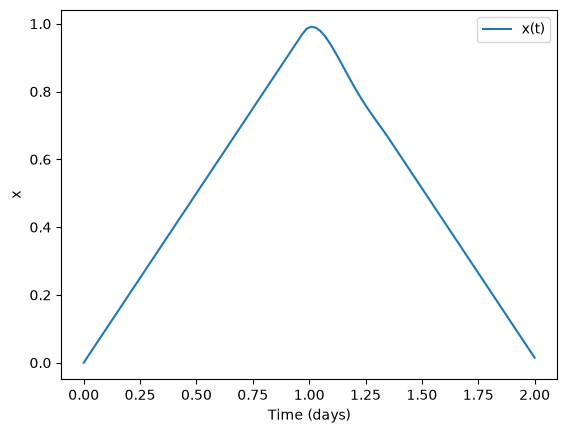

In [ ]:
import numpy as np
from pybm.model import Model, Var, Const
from pybm.estimate.int_scipy import simulate as simulate_scipy
from pybm.estimate.int_scipy import estimate as estimate_scipy
x = Var("x", initial=0, type="endo")

model = Model(x)

t = np.linspace(0, 2, 100)

def rhs(t, ctx):
    if t <= 1:
        return 1
    else:
        return -1

x.ode = rhs 

# simulate 
sol = simulate_scipy(x, t_eval=t, const_ctx=[])

plt.plot(t, sol.y[0], label="x(t)")
plt.xlabel("Time (days)")
plt.ylabel("x")
plt.legend()
plt.show()


Estimation with if statements in ode:

In [ ]:
import numpy as np
from pybm.model import Model, Var, Const
from pybm.estimate.int_scipy import set_consts
from pybm.estimate.int_scipy import simulate as simulate_scipy
from pybm.estimate.int_scipy import estimate as estimate_scipy
x = Var("x", initial=0, type="endo")
c1 = Const("c1", initial_value=0)
c2 = Const("c2", initial_value=0)

model = Model(x, c1, c2)



def rhs(t, ctx):
    if t <= 1:
        return c1(ctx)
    else:
        return c2(ctx)
# add equation
x.ode = rhs 
# add data for x - use previously simulated data
x.set_data(t,sol.y[0] )


# estimate constants with SciPy
const_ctx, loss = estimate_scipy(model=model, t_eval=t, verbose=2)  # verbose=2 for more detailed output

# set the estimated values of the constants in the model
set_consts(model, const_ctx)

print("\nEstimated values of the constants:")
print("c1:", c1.initial_value)
print("c2:", c2.initial_value)

Estimating constants using least squares optimization...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.6928e+01                                    5.03e+01    
       1              2         3.9996e-01      1.65e+01       1.00e+00       1.87e+00    
       2              3         1.9234e-01      2.08e-01       2.24e-01       7.09e+00    
       3              4         1.5378e-01      3.86e-02       2.28e-02       3.73e-01    
       4              5         1.5344e-01      3.43e-04       1.37e-02       3.83e-02    
       5              6         1.5341e-01      2.70e-05       4.34e-03       2.41e-02    
       6              7         1.5341e-01      3.13e-06       1.41e-03       6.62e-03    
       7              8         1.5341e-01      3.10e-07       4.50e-04       2.22e-03    
       8              9         1.5341e-01      3.17e-08       1.43e-04       6.96e-04    
`gtol` termination condition is s

ValueError: too many values to unpack (expected 2)

## Constants in condition

Let us first study a clasical optimisation problem without any ODE integration. We have a model 
$$
f_c(x) = \begin{cases}
a & x \leq c \\
b & x > c
\end{cases}
$$
and ground truth f_1(x). We only have access to a sample of values $(x_i, f_1(x_i))_{i = 1}^n$ and we want to optimize $c$ based on this values.
We want to optimize mean squared error on a sample:
$$
\mathcal L (c) = \sum_{i = 1}^n  (f_1(x_i) - f_c(x_i))^2,
$$
which **has zero gradient** (where it exists). 
If our optimizing algorithm is gradient-based (`least_squares` from `scipy`,...), than optimisation wont work. In order to use 
gradient-based methods, one can relaxe the problem with introducing relaxed model such as
$$
f_c(x) = \frac{tanh(\frac{c - a}{\epsilon}) + 1}{2}(b-a) + a,
$$
which is suitable for gradient-based optimisation.

In [ ]:
import matplotlib.pyplot as plt

a = 1
b = 2
f = lambda x : a if x <= 1 else b
relaxed_f = lambda x : 0.5 * (1 + np.tanh((x-a)/0.1))*(b-a) + a
ts = np.linspace(0, 2, 100)
fs = [f(t) for t in ts]
rfs = [relaxed_f(t) for t in ts]

plt.figure(figsize=(4, 4))
plt.plot(ts, fs, label="f(x)")
plt.plot(ts, rfs, label="relaxed f(x)")
plt.legend()
plt.show()


PyBM implements **relaxed if-esle** statements with `pybm.conditional.RelaxedIfElse`. In order to use gradient-based methods for estimation, this conditionals (or other relaxed versions) should be used instead of vanilla if-else.

Not all if-else statements can be converted into relaxed versions. Suitable ones can be written in a form 
```
if value_1 <= 0:
    expr_1 
elif value_2 <= 0:
    expr_2
    .
    .
    .
elif value_n <= 0:
    expr_n
else:
    expr_n+1
```
and are rewritten in relaxed form as 
```
RelaxedIfElse().If(value_1, expr_1).Elif(value_2,expr_2)....Elif(value_n, expr_n).Else(expr_n+1)
```

In [ ]:
from pybm.conditional import RelaxedIfElse

eps = 0.2
def rf_tanh(x):
    return RelaxedIfElse(eps=eps).If(x-1,a).Else(b)

def rf_erf(x):
    return RelaxedIfElse(eps=eps, method="erf").If(x-1,a).Else(b)

def rf_linear(x):
    return RelaxedIfElse(eps=eps, method="linear").If(x-1,a).Else(b)

rfs_tanh = [rf_tanh(t) for t in ts]
rfs_erf = [rf_erf(t) for t in ts]
rfs_linear = [rf_linear(t) for t in ts]

plt.figure(figsize=(4, 4))
plt.plot(ts, fs, label="f(x)")
plt.plot(ts, rfs_tanh, label="relaxed with tanh")
plt.plot(ts, rfs_erf, label="relaxed with erf")
plt.plot(ts, rfs_linear, label="relaxed with linear")
plt.legend(loc="upper left")
plt.show()

Now we will again try to model the data $(t_i,x_i)_{i}$, sampled with noise from equation 
$$
x' = \begin{cases} 1 & t \leq 1 \\ -1 & t  >  1 \end{cases}
$$
but this time, we will use a model with constant inside if condition: 
$x' = \begin{cases} 1 & t \leq c \\ -1 & t  >  c \end{cases}$ and try to estimate $c$. 

In [ ]:
import numpy as np
from pybm.model import Model, Var, Const
from pybm.estimate.int_scipy import set_consts
from pybm.estimate.int_scipy import simulate as simulate_scipy
from pybm.estimate.int_scipy import estimate as estimate_scipy

x = Var("x", initial=0, type="endo")
c = Const("c", initial_value=0.5)
model = Model(x, c)

############################################################
## prepare artifitial data                                 #
t = np.linspace(0, 2, 100)                                 #    
                                                           #
def rhs(t, ctx):                                           # 
    if t <= 1:                                             #
        return 1                                           #
    else:                                                  #
        return -1                                          #
                                                           #
x.ode = rhs                                                #
                                                           #       
# simulate                                                 # 
sol = simulate_scipy(x, t_eval=t, const_ctx=[])            #
# save and add noise to the data for x                     #            
noise = np.random.normal(0, 0.01, size=sol.y[0].shape)      #
true_x = sol.y[0] + noise                                  #
############################################################



# Use relaxed if-else in the ODE definition
def rhs(t, ctx):
    return RelaxedIfElse(eps=0.01).If(t-c(ctx), 1).Else(-1)
    
# add equation
x.ode = rhs 
# add data for x - use previously simulated data
x.set_data(t,true_x)



# estimate constants with SciPy
const_ctx, loss = estimate_scipy(model=model, t_eval=t, verbose=2)  # verbose=2 for more detailed output

print(const_ctx, ", ", loss)

# set the estimated values of the constants in the model
set_consts(model, const_ctx)

print("\nEstimated values of the constants:")
print("c:", c.initial_value)
const_ctx

In [ ]:
import numpy as np
from pybm.model import Model, Var, Const
from pybm.estimate.int_scipy import set_consts
from pybm.estimate.int_scipy import simulate as simulate_scipy
from pybm.estimate.int_scipy import estimate as estimate_scipy

x = Var("x", initial=0, type="endo")
# add data for x - use previously simulated data
x.set_data(t,true_x)

# new model
c_1 = Const("c_1", initial_value=0.5)
c_2 = Const("c_2", initial_value=1.5)
t_0 = Const("t_0", initial_value=0.5)
model = Model(x, t_0, c_1, c_2)




# Use relaxed if-else in the ODE definition
def rhs(t, ctx):
    return RelaxedIfElse(eps=0.01).If(t-t_0(ctx), c_1(ctx)).Else(c_2(ctx))
    
# add equation
x.ode = rhs 




# estimate constants with SciPy
const_ctx, loss = estimate_scipy(model=model, t_eval=t, verbose=2)  # verbose=2 for more detailed output

print(const_ctx, ", ", loss)

# set the estimated values of the constants in the model
set_consts(model, const_ctx)

print("\nEstimated values of the constants:")
print("c_1:", c_1.initial_value)
print("c_2:", c_2.initial_value)
print("t_0:", t_0.initial_value)
const_ctx

This way, fitting works even for constants, used in conditions. Convergence strongly depends on the **hyperparameter `eps`** inside `RelaxedIfElse(eps=...)`. 
Large values of `eps` will result in bad approximations of a model. Small values will resolut in slow or unsuccessful convergence.

### Example - more constants
Lets now study the previous dataset with a more complicated model 
$x' = \begin{cases} c_1 & t \leq t_0 \\ c_2 & t  >  t_0 \end{cases}$.

## Choose between different equations

In [ ]:
from pybm.model import Choose

# create a fresh model and add a simple entity 
model = Model()
particle = Entity(Var("x"), name="particle", active_model=model)

# add equation for the particle 
# right side of the equation: 
def rs_exp(t):
    return particle["x"]

def rs_const(t):
    return 0 

# add a choice for the right side of the equation
particle.get("x").ode = Choose(rs_exp, rs_const)

#################################
# induce models
#################################

induced_models = model.induce()
for i, model in enumerate(induced_models):
    print(f"Induced model {i}:")
    print(str(model))
    print("equation:" , model.vars["particle.x"].ode)

# New features
- gradient-based estimation (in progress, add multishooting and/or cmaes for initial value of a c-trajectory)
- constants inside if-statements - solved with `RelaxedIfElse`

# On CMA-ES
CMA-ES is gradient-free method, which replaces derivation by estimation of the parameters of a normal distribution.  TODO

- ~~TODO urgently need a stopper for simulate, which will stop in case of large errors or very small steps in ODE. ODE simulation takes to much time if the parameters are selected randomly.~~ Even with stoppers, opt is slow

# TODO 

## Urgent  
- CMAES , Jax
- Constants inside if statements (` if f(c) ...`) -- Done ✅ *solved with `RelaxedIfElse`*
- Implement `Process` and `ProcessTemplate`
- Finish induction of models 
- Automatically conver ProBMoT to PyBM code (as in 
[/PyBM/bled/bled.py](/home/urhp/Documents/PyBM/bled/bled.py))

## Other
- JAX (better implementations of optimisation algos)
- test different algoritms
- better estimation:
  - Short hyperparam search 
  - Integrate on smaller intervals, use multi-shooting, continue just if trajectory is good, use priority queue on different models 
  - Stop integration, if the error of integration is too big (no additional knowledge!)
  - if the data is dense, use **numerical derivatives** for speedup 
- Improved syntax  
- AutoML on the data??
